In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import scienceplots
import matplotlib as mpl
from tqdm import tqdm
from scipy.stats.mstats import ttest_onesamp
from scipy.optimize import curve_fit


#mpl.rcParams.update(mpl.rcParamsDefault)
plt.style.use(['science','notebook'])


CB_color_cycle = ['#377eb8', '#ff7f00', '#4daf4a',
                  '#f781bf', '#a65628', '#984ea3',
                  '#999999', '#e41a1c', '#dede00']

plt.rcParams['axes.prop_cycle'] = plt.cycler(color=CB_color_cycle)



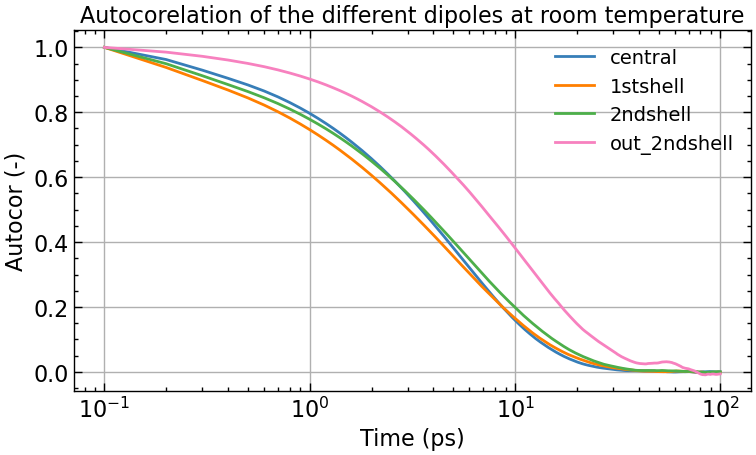

In [19]:
fig, ax = plt.subplots()

ax.set_xscale('log')
ax.set_xlabel("Time (ps)")
ax.set_ylabel("Autocor (-)")
ax.set_title("Autocorelation of the different dipoles at room temperature")
Name = "central"
Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
Rescale = Data[0,1]
Data[:,1]/= Rescale
Data[:,2]/= Rescale
Data[:,0]/=1000
prevplot = ax.plot(Data[:,0], Data[:,1], label = Name)
ax.fill_between(Data[:,0], Data[:,1]-Data[:,2], Data[:,1]+Data[:,2], alpha=0.3, lw=0)


Name = "1stshell"
Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
Rescale = Data[0,1]
Data[:,1]/= Rescale
Data[:,2]/= Rescale
Data[:,0]/=1000
prevplot = ax.plot(Data[:,0], Data[:,1], label = Name)
ax.fill_between(Data[:,0], Data[:,1]-Data[:,2], Data[:,1]+Data[:,2], alpha=0.3, lw=0)

Name = "2ndshell"
Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
Rescale = Data[0,1]
Data[:,1]/= Rescale
Data[:,2]/= Rescale
Data[:,0]/=1000
prevplot = ax.plot(Data[:,0], Data[:,1], label = Name)
ax.fill_between(Data[:,0], Data[:,1]-Data[:,2], Data[:,1]+Data[:,2], alpha=0.3, lw=0)

# Name = "out_1stshell"
# Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
# Rescale = Data\n[0,1] Data[:,1]/= Rescale
# Data[:,2]/=Data[0,1]
# Data[:,0]/=1000
# prevplot = ax.plot(Data[:,0], Data[:,1], label = Name)
# ax.fill_between(Data[:,0], Data[:,1]-Data[:,2], Data[:,1]+Data[:,2], alpha=0.3, lw=0)

Name = "out_2ndshell"
Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
Rescale = Data[0,1]
Data[:,1]/= Rescale
Data[:,2]/= Rescale
Data[:,0]/=1000
prevplot = ax.plot(Data[:,0], Data[:,1], label = Name)
ax.fill_between(Data[:,0], Data[:,1]-Data[:,2], Data[:,1]+Data[:,2], alpha=0.3, lw=0)

ax.legend()
ax.grid()
fig.set_size_inches((8,5))
plt.tight_layout()
plt.savefig("autocorr_RoomT.png")
plt.show()


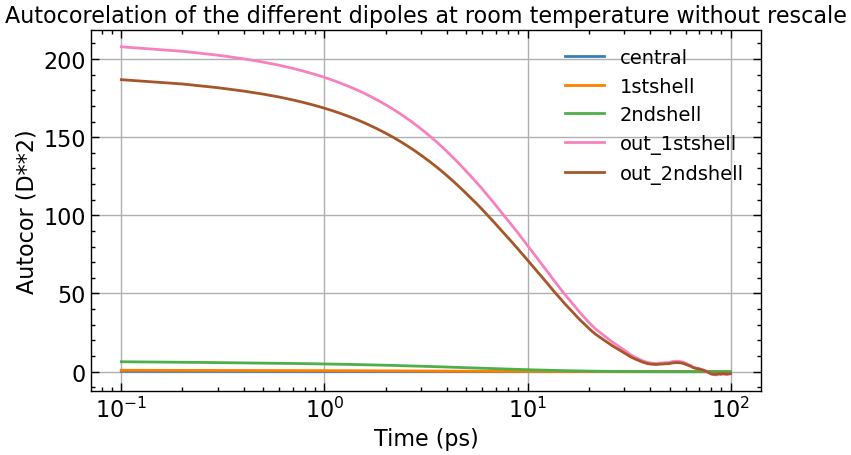

In [20]:
fig, ax = plt.subplots()

ax.set_xscale('log')
ax.set_xlabel("Time (ps)")
ax.set_ylabel("Autocor (D**2)")
ax.set_title("Autocorelation of the different dipoles at room temperature without rescale")
Name = "central"
Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
#Rescale = Data\n[0,1] Data[:,1]/= Rescale
#Data[:,2]/=Data[0,1]
Data[:,0]/=1000
prevplot = ax.plot(Data[:,0], Data[:,1], label = Name)
ax.fill_between(Data[:,0], Data[:,1]-Data[:,2], Data[:,1]+Data[:,2], alpha=0.3, lw=0)


Name = "1stshell"
Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
#Rescale = Data\n[0,1] Data[:,1]/= Rescale
#Data[:,2]/=Data[0,1]
Data[:,0]/=1000
prevplot = ax.plot(Data[:,0], Data[:,1], label = Name)
ax.fill_between(Data[:,0], Data[:,1]-Data[:,2], Data[:,1]+Data[:,2], alpha=0.3, lw=0)

Name = "2ndshell"
Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
#Rescale = Data\n[0,1] Data[:,1]/= Rescale
#Data[:,2]/=Data[0,1]
Data[:,0]/=1000
prevplot = ax.plot(Data[:,0], Data[:,1], label = Name)
ax.fill_between(Data[:,0], Data[:,1]-Data[:,2], Data[:,1]+Data[:,2], alpha=0.3, lw=0)

Name = "out_1stshell"
Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
#Rescale = Data\n[0,1] Data[:,1]/= Rescale
#Data[:,2]/=Data[0,1]
Data[:,0]/=1000
prevplot = ax.plot(Data[:,0], Data[:,1], label = Name)
ax.fill_between(Data[:,0], Data[:,1]-Data[:,2], Data[:,1]+Data[:,2], alpha=0.3, lw=0)

Name = "out_2ndshell"
Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
#Rescale = Data\n[0,1] Data[:,1]/= Rescale
#Data[:,2]/=Data[0,1]
Data[:,0]/=1000
prevplot = ax.plot(Data[:,0], Data[:,1], label = Name)
ax.fill_between(Data[:,0], Data[:,1]-Data[:,2], Data[:,1]+Data[:,2], alpha=0.3, lw=0)

ax.legend()
ax.grid()
fig.set_size_inches((8,5))
plt.tight_layout()
plt.show()

In [21]:
def exp_model(x,a):
    return np.exp(-x/a)

In [22]:
Name = "central"
Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
Rescale = Data[0,1]
Data[:,1]/= Rescale
Data[:,2]/= Rescale
Data[:,0]/=1000 # ps
popt, pcov = curve_fit(exp_model, Data[:,0], Data[:,1])
a_ref = popt[0]
sig_ref = np.sqrt(pcov[0][0])
genData_ref = exp_model(Data[:,0],a_ref)

In [23]:
Name = "1stshell"
Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
Rescale = Data[0,1]
Data[:,1]/= Rescale
Data[:,2]/= Rescale
Data[:,0]/=1000 # mpsicros
popt, pcov = curve_fit(exp_model, Data[:,0], Data[:,1])
a_1st = popt[0]
sig_1st = np.sqrt(pcov[0][0])

genData_1st = exp_model(Data[:,0],a_1st)

In [24]:
Name = "2ndshell"
Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
Rescale = Data[0,1]
Data[:,1]/= Rescale
Data[:,2]/= Rescale
Data[:,0]/=1000 #ps
popt, pcov = curve_fit(exp_model, Data[:,0], Data[:,1])
a_2nd = popt[0]
sig_2nd = np.sqrt(pcov[0][0])

genData_2nd = exp_model(Data[:,0],a_2nd)

In [25]:
Name = "out_1stshell"
Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
Rescale = Data[0,1]
Data[:,1]/= Rescale
Data[:,2]/= Rescale
Data[:,0]/=1000 #ps
popt, pcov = curve_fit(exp_model, Data[:,0], Data[:,1])
a_out_1st = popt[0]
sig_out_1st = np.sqrt(pcov[0][0])

genData_out_1st = exp_model(Data[:,0],a_out_1st)

In [26]:
Name = "out_2ndshell"
Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
Rescale = Data[0,1]
Data[:,1]/= Rescale
Data[:,2]/= Rescale
Data[:,0]/=1000 # ps
popt, pcov = curve_fit(exp_model, Data[:,0], Data[:,1])
a_out_2nd = popt[0]
sig_out_2nd = np.sqrt(pcov[0][0])

genData_out_2nd = exp_model(Data[:,0],a_out_2nd)

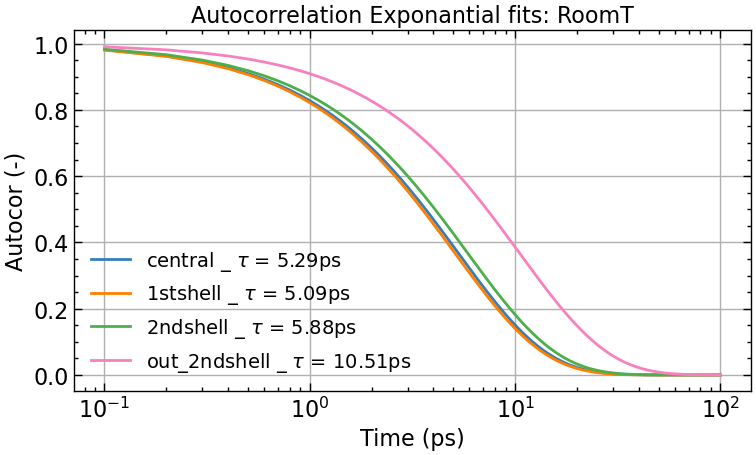

In [27]:
fig, ax = plt.subplots()

ax.set_xscale('log')
ax.set_xlabel("Time (ps)")
ax.set_ylabel("Autocor (-)")
ax.set_title("Autocorrelation Exponantial fits: RoomT")



Name = "central"
Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
Rescale = Data[0,1]
Data[:,1]/= Rescale
Data[:,2]/= Rescale
Data[:,0]/=1000
ax.plot(Data[:,0], genData_ref, label = f"{Name} _ $\\tau$ = {a_ref:.2f}ps ")


Name = "1stshell"
Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
Rescale = Data[0,1]
Data[:,1]/= Rescale
Data[:,2]/= Rescale
Data[:,0]/=1000
prevplot = ax.plot(Data[:,0], genData_1st, label = f"{Name} _ $\\tau$ = {a_1st:.2f}ps ")

Name = "2ndshell"
Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
Rescale = Data[0,1]
Data[:,1]/= Rescale
Data[:,2]/= Rescale
Data[:,0]/=1000
prevplot = ax.plot(Data[:,0], genData_2nd, label = f"{Name} _ $\\tau$ = {a_2nd:.2f}ps ")

# Name = "out_1stshell"
# Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
# Rescale = Data\n[0,1] Data[:,1]/= Rescale
# Data[:,2]/=Data[0,1]
# Data[:,0]/=1000000
# prevplot = ax.plot(Data[:,0], genData_out_1st, label = Name)

Name = "out_2ndshell"
Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
Rescale = Data[0,1]
Data[:,1]/= Rescale
Data[:,2]/= Rescale
Data[:,0]/=1000
prevplot = ax.plot(Data[:,0], genData_out_2nd, label = f"{Name} _ $\\tau$ = {a_out_2nd:.2f}ps ")

ax.legend()
ax.grid()
fig.set_size_inches((8,5))
plt.tight_layout()
plt.savefig("fit_autocorr_RoomT.pdf")
plt.savefig("fit_autocorr_RoomT.png")

plt.show()


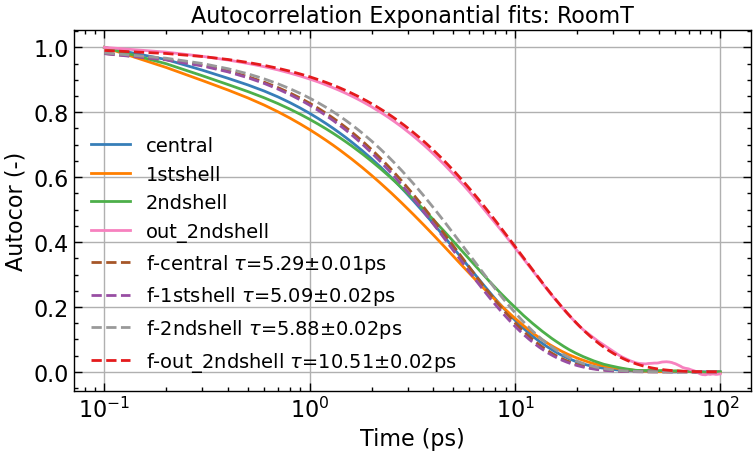

In [28]:
fig, ax = plt.subplots()

ax.set_xscale('log')
ax.set_xlabel("Time (ps)")
ax.set_ylabel("Autocor (-)")
ax.set_title("Autocorrelation Exponantial fits: RoomT")
#ax.set_xlim((0,1e3))
#ax.set_ylim((-0.5,1.5))

Name = "central"
Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
Rescale = Data[0,1]
Data[:,1]/= Rescale
Data[:,2]/= Rescale
Data[:,0]/=1000
prevplot = ax.plot(Data[:,0], Data[:,1], label = Name)
ax.fill_between(Data[:,0], Data[:,1]-Data[:,2], Data[:,1]+Data[:,2], alpha=0.3, lw=0)

Name = "1stshell"
Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
Rescale = Data[0,1]
Data[:,1]/= Rescale
Data[:,2]/= Rescale
Data[:,0]/=1000
prevplot = ax.plot(Data[:,0], Data[:,1], label = Name)
ax.fill_between(Data[:,0], Data[:,1]-Data[:,2], Data[:,1]+Data[:,2], alpha=0.3, lw=0)

Name = "2ndshell"
Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
Rescale = Data[0,1]
Data[:,1]/= Rescale
Data[:,2]/= Rescale
Data[:,0]/=1000
prevplot = ax.plot(Data[:,0], Data[:,1], label = Name)
ax.fill_between(Data[:,0], Data[:,1]-Data[:,2], Data[:,1]+Data[:,2], alpha=0.3, lw=0)

# Name = "out_1stshell"
# Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
# Rescale = Data\n[0,1] Data[:,1]/= Rescale
# Data[:,2]/=Data[0,1]
# Data[:,0]/=1000000
# prevplot = ax.plot(Data[:,0], Data[:,1], label = Name)
# ax.fill_between(Data[:,0], Data[:,1]-Data[:,2], Data[:,1]+Data[:,2], alpha=0.3, lw=0)

Name = "out_2ndshell"
Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
Rescale = Data[0,1]
Data[:,1]/= Rescale
Data[:,2]/= Rescale
Data[:,0]/=1000
prevplot = ax.plot(Data[:,0], Data[:,1], label = Name)
ax.fill_between(Data[:,0], Data[:,1]-Data[:,2], Data[:,1]+Data[:,2], alpha=0.3, lw=0)


Name = "central"
Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
Rescale = Data[0,1]
Data[:,1]/= Rescale
Data[:,2]/= Rescale
Data[:,0]/=1000
prevplot = ax.plot(Data[:,0], genData_ref, label = f"f-{Name} $\\tau$={a_ref:.2f}$\\pm${sig_ref:.2f}ps", linestyle = '--')


Name = "1stshell"
Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
Rescale = Data[0,1]
Data[:,1]/= Rescale
Data[:,2]/= Rescale
Data[:,0]/=1000
prevplot = ax.plot(Data[:,0], genData_1st, label = f"f-{Name} $\\tau$={a_1st:.2f}$\\pm${sig_1st:.2f}ps", linestyle = '--')

Name = "2ndshell"
Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
Rescale = Data[0,1]
Data[:,1]/= Rescale
Data[:,2]/= Rescale
Data[:,0]/=1000
prevplot = ax.plot(Data[:,0], genData_2nd, label = f"f-{Name} $\\tau$={a_2nd:.2f}$\\pm${sig_2nd:.2f}ps", linestyle = '--')

# Name = "out_1stshell"
# Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
# Rescale = Data\n[0,1] Data[:,1]/= Rescale
# Data[:,2]/=Data[0,1]
# Data[:,0]/=1000000
# prevplot = ax.plot(Data[:,0], genData_out_1st, label = Name)

Name = "out_2ndshell"
Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
Rescale = Data[0,1]
Data[:,1]/= Rescale
Data[:,2]/= Rescale
Data[:,0]/=1000
prevplot = ax.plot(Data[:,0], genData_out_2nd, label = f"f-{Name} $\\tau$={a_out_2nd:.2f}$\\pm${sig_out_2nd:.2f}ps", linestyle = '--')

ax.legend()
ax.grid()
fig.set_size_inches((8,5))
plt.tight_layout()
plt.savefig("fitnraw_autocorr_RoomT.pdf")

plt.show()


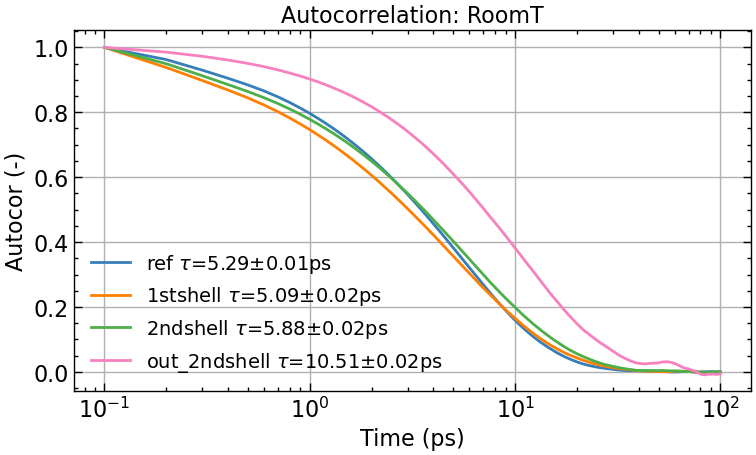

In [29]:
fig, ax = plt.subplots()

ax.set_xscale('log')
ax.set_xlabel("Time (ps)")
ax.set_ylabel("Autocor (-)")
ax.set_title("Autocorrelation: RoomT")
#ax.set_xlim((0,1e3))
#ax.set_ylim((-0.5,1.5))

Name = "central"
Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
Rescale = Data[0,1]
Data[:,1]/= Rescale
Data[:,2]/= Rescale
Data[:,0]/=1000
prevplot = ax.plot(Data[:,0], Data[:,1], label = f"ref $\\tau$={a_ref:.2f}$\\pm${sig_ref:.2f}ps")
ax.fill_between(Data[:,0], Data[:,1]-Data[:,2], Data[:,1]+Data[:,2], alpha=0.3, lw=0)

Name = "1stshell"
Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
Rescale = Data[0,1]
Data[:,1]/= Rescale
Data[:,2]/= Rescale
Data[:,0]/=1000
prevplot = ax.plot(Data[:,0], Data[:,1], label = f"{Name} $\\tau$={a_1st:.2f}$\\pm${sig_1st:.2f}ps")
ax.fill_between(Data[:,0], Data[:,1]-Data[:,2], Data[:,1]+Data[:,2], alpha=0.3, lw=0)

Name = "2ndshell"
Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
Rescale = Data[0,1]
Data[:,1]/= Rescale
Data[:,2]/= Rescale
Data[:,0]/=1000
prevplot = ax.plot(Data[:,0], Data[:,1], label = f"{Name} $\\tau$={a_2nd:.2f}$\\pm${sig_2nd:.2f}ps")
ax.fill_between(Data[:,0], Data[:,1]-Data[:,2], Data[:,1]+Data[:,2], alpha=0.3, lw=0)

# Name = "out_1stshell"
# Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
# Rescale = Data\n[0,1] Data[:,1]/= Rescale
# Data[:,2]/=Data[0,1]
# Data[:,0]/=1000000
# prevplot = ax.plot(Data[:,0], Data[:,1], label = Name)
# ax.fill_between(Data[:,0], Data[:,1]-Data[:,2], Data[:,1]+Data[:,2], alpha=0.3, lw=0)

Name = "out_2ndshell"
Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
Rescale = Data[0,1]
Data[:,1]/= Rescale
Data[:,2]/= Rescale
Data[:,0]/=1000
prevplot = ax.plot(Data[:,0], Data[:,1], label = f"{Name} $\\tau$={a_out_2nd:.2f}$\\pm${sig_out_2nd:.2f}ps")
ax.fill_between(Data[:,0], Data[:,1]-Data[:,2], Data[:,1]+Data[:,2], alpha=0.3, lw=0)


# Name = "central"
# Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
# Rescale = Data\n[0,1] Data[:,1]/= Rescale
# Data[:,2]/=Data[0,1]
# Data[:,0]/=1000
# prevplot = ax.plot(Data[:,0], genData_ref, label = f"f-{Name} $\\tau$={a_ref:.2f}$\\pm${sig_ref:.2f}ps", linestyle = '--')


# Name = "1stshell"
# Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
# Rescale = Data\n[0,1] Data[:,1]/= Rescale
# Data[:,2]/=Data[0,1]
# Data[:,0]/=1000
# prevplot = ax.plot(Data[:,0], genData_1st, label = f"f-{Name} $\\tau$={a_1st:.2f}$\\pm${sig_1st:.2f}ps", linestyle = '--')

# Name = "2ndshell"
# Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
# Rescale = Data\n[0,1] Data[:,1]/= Rescale
# Data[:,2]/=Data[0,1]
# Data[:,0]/=1000
# prevplot = ax.plot(Data[:,0], genData_2nd, label = f"f-{Name} $\\tau$={a_2nd:.2f}$\\pm${sig_2nd:.2f}ps", linestyle = '--')

# Name = "out_1stshell"
# Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
# Rescale = Data\n[0,1] Data[:,1]/= Rescale
# Data[:,2]/=Data[0,1]
# Data[:,0]/=1000000
# prevplot = ax.plot(Data[:,0], genData_out_1st, label = Name)

# Name = "out_2ndshell"
# Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
# Rescale = Data\n[0,1] Data[:,1]/= Rescale
# Data[:,2]/=Data[0,1]
# Data[:,0]/=1000
# prevplot = ax.plot(Data[:,0], genData_out_2nd, label = f"f-{Name} $\\tau$={a_out_2nd:.2f}$\\pm${sig_out_2nd:.2f}ps", linestyle = '--')

ax.legend()
ax.grid()
fig.set_size_inches((8,5))
plt.tight_layout()
plt.savefig("rawntime_autocorr_RoomT.pdf", dpi=300)
plt.savefig("rawntime_autocorr_RoomT.png", dpi=300)
plt.show()

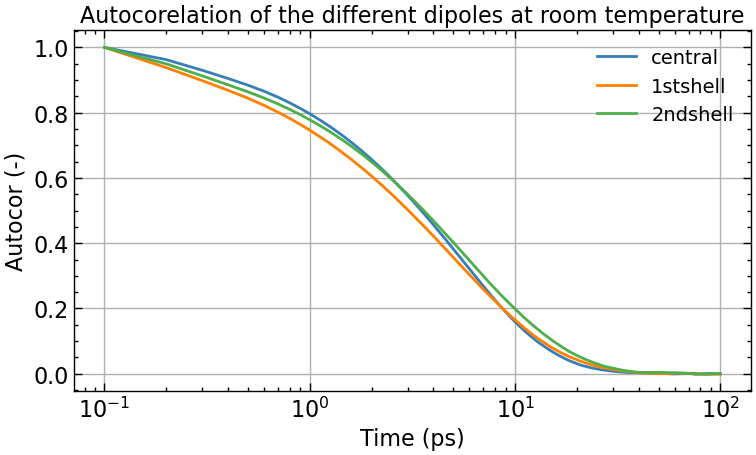

In [30]:
fig, ax = plt.subplots()

ax.set_xscale('log')
ax.set_xlabel("Time (ps)")
ax.set_ylabel("Autocor (-)")
ax.set_title("Autocorelation of the different dipoles at room temperature")
Name = "central"
Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
Rescale = Data[0,1]
Data[:,1]/= Rescale
Data[:,2]/= Rescale
Data[:,0]/=1000
prevplot = ax.plot(Data[:,0], Data[:,1], label = Name)
ax.fill_between(Data[:,0], Data[:,1]-Data[:,2], Data[:,1]+Data[:,2], alpha=0.3, lw=0)


Name = "1stshell"
Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
Rescale = Data[0,1]
Data[:,1]/= Rescale
Data[:,2]/= Rescale
Data[:,0]/=1000
prevplot = ax.plot(Data[:,0], Data[:,1], label = Name)
ax.fill_between(Data[:,0], Data[:,1]-Data[:,2], Data[:,1]+Data[:,2], alpha=0.3, lw=0)

Name = "2ndshell"
Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
Rescale = Data[0,1]
Data[:,1]/= Rescale
Data[:,2]/= Rescale
Data[:,0]/=1000
prevplot = ax.plot(Data[:,0], Data[:,1], label = Name)
ax.fill_between(Data[:,0], Data[:,1]-Data[:,2], Data[:,1]+Data[:,2], alpha=0.3, lw=0)

# Name = "out_1stshell"
# Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
# Rescale = Data\n[0,1] Data[:,1]/= Rescale
# Data[:,2]/=Data[0,1]
# Data[:,0]/=1000
# prevplot = ax.plot(Data[:,0], Data[:,1], label = Name)
# ax.fill_between(Data[:,0], Data[:,1]-Data[:,2], Data[:,1]+Data[:,2], alpha=0.3, lw=0)

# Name = "out_2ndshell"
# Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
# Rescale = Data\n[0,1] Data[:,1]/= Rescale
# Data[:,2]/=Data[0,1]
# Data[:,0]/=1000
# prevplot = ax.plot(Data[:,0], Data[:,1], label = Name)
# ax.fill_between(Data[:,0], Data[:,1]-Data[:,2], Data[:,1]+Data[:,2], alpha=0.3, lw=0)

ax.legend()
ax.grid()
fig.set_size_inches((8,5))
plt.tight_layout()
plt.savefig("autocorr_RoomT.pdf")
plt.show()

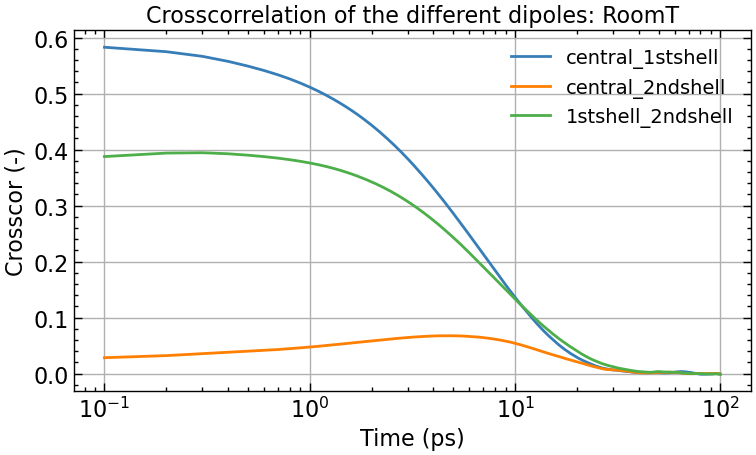

In [31]:
fig, ax = plt.subplots()

ax.set_xscale('log')
ax.set_xlabel("Time (ps)")
ax.set_ylabel("Crosscor (-)")
ax.set_title("Crosscorrelation of the different dipoles: RoomT")
#ax.set_xlim((0,1e3))

Name = "central_1stshell"
Subnames=Name.split('_')
Data = np.loadtxt(f"dipole_{Name}_crosscor_mean_v3.txt")[1:,:]
Subdata1 = np.loadtxt(f"dipole_{Subnames[0]}_cor_mean_v3.txt")[1:,:]
Subdata2 = np.loadtxt(f"dipole_{Subnames[1]}_cor_mean_v3.txt")[1:,:]
Data[:,1]/=(np.sqrt(Subdata1[0,1]*Subdata2[0,1]))
Data[:,2]/=(np.sqrt(Subdata1[0,1]*Subdata2[0,1]))
Data[:,0]/=1000
prevplot = ax.plot(Data[:,0], Data[:,1], label = Name)
ax.fill_between(Data[:,0], Data[:,1]-Data[:,2], Data[:,1]+Data[:,2], alpha=0.3, lw=0)

Name = "central_2ndshell"
Subnames=Name.split('_')
Data = np.loadtxt(f"dipole_{Name}_crosscor_mean_v3.txt")[1:,:]
Subdata1 = np.loadtxt(f"dipole_{Subnames[0]}_cor_mean_v3.txt")[1:,:]
Subdata2 = np.loadtxt(f"dipole_{Subnames[1]}_cor_mean_v3.txt")[1:,:]
Data[:,1]/=(np.sqrt(Subdata1[0,1]*Subdata2[0,1]))
Data[:,2]/=(np.sqrt(Subdata1[0,1]*Subdata2[0,1]))
Data[:,0]/=1000
prevplot = ax.plot(Data[:,0], Data[:,1], label = Name)
ax.fill_between(Data[:,0], Data[:,1]-Data[:,2], Data[:,1]+Data[:,2], alpha=0.3, lw=0)

Name = "1stshell_2ndshell"
Subnames=Name.split('_')
Data = np.loadtxt(f"dipole_{Name}_crosscor_mean_v3.txt")[1:,:]
Subdata1 = np.loadtxt(f"dipole_{Subnames[0]}_cor_mean_v3.txt")[1:,:]
Subdata2 = np.loadtxt(f"dipole_{Subnames[1]}_cor_mean_v3.txt")[1:,:]
Data[:,1]/=(np.sqrt(Subdata1[0,1]*Subdata2[0,1]))
Data[:,2]/=(np.sqrt(Subdata1[0,1]*Subdata2[0,1]))
Data[:,0]/=1000
prevplot = ax.plot(Data[:,0], Data[:,1], label = Name)
ax.fill_between(Data[:,0], Data[:,1]-Data[:,2], Data[:,1]+Data[:,2], alpha=0.3, lw=0)


ax.legend()
ax.grid()
fig.set_size_inches((8,5))
plt.tight_layout()
plt.savefig("crosscorr_RoomT.pdf")
plt.savefig("crosscorr_RoomT.png")

plt.show()


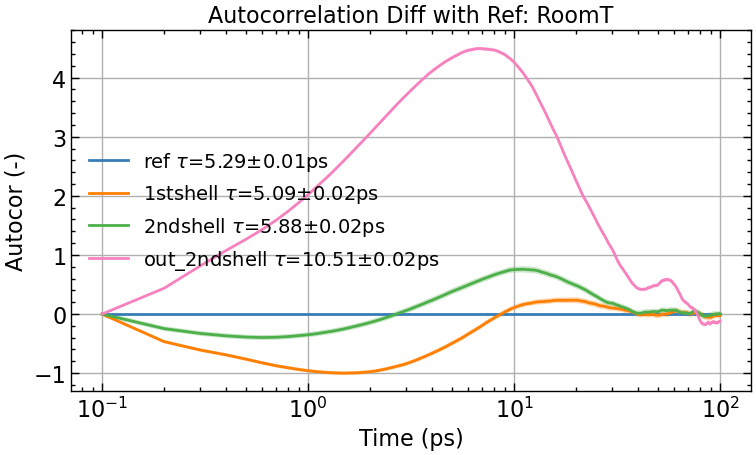

In [32]:
fig, ax = plt.subplots()

Name = "central"
Ref = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
Rescale = Ref[0,1]
Ref[:,1]/=Rescale
Ref[:,2]/=Rescale
Ref[:,0]/=1000

ax.set_xscale('log')
ax.set_xlabel("Time (ps)")
ax.set_ylabel("Autocor (-)")
ax.set_title("Autocorrelation Diff with Ref: RoomT")
#ax.set_xlim((0,1e3))
#ax.set_ylim((-0.5,1.5))

Name = "central"
Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
Rescale = Data[0,1]
Data[:,1]/= Rescale
Data[:,2]/= Rescale
Data[:,0]/=1000

Data[:,1] -= Ref[:,1]
Data[:,2] += Ref[:,2]
#Data_absmax = np.max(np.abs(Data[:,1]))
# Data[:,1] /= Data_absmax
# Data[:,2] /= Data_absmax

prevplot = ax.plot(Data[:,0], Data[:,1], label = f"ref $\\tau$={a_ref:.2f}$\\pm${sig_ref:.2f}ps")
ax.fill_between(Data[:,0], Data[:,1]-Data[:,2], Data[:,1]+Data[:,2], alpha=0.3, lw=0)

Name = "1stshell"
Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
Rescale = Data[0,1]
Data[:,1]/= Rescale
Data[:,2]/= Rescale
Data[:,0]/=1000

Data[:,1] -= Ref[:,1]
Data[:,2] += Ref[:,2]
Data_absmax = np.max(np.abs(Data[:,1]))
Data[:,1] /= Data_absmax
Data[:,2] /= Data_absmax

prevplot = ax.plot(Data[:,0], Data[:,1], label = f"{Name} $\\tau$={a_1st:.2f}$\\pm${sig_1st:.2f}ps")
ax.fill_between(Data[:,0], Data[:,1]-Data[:,2], Data[:,1]+Data[:,2], alpha=0.3, lw=0)

Name = "2ndshell"
Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
Rescale = Data[0,1]
Data[:,1]/= Rescale
Data[:,2]/= Rescale
Data[:,0]/=1000

Data[:,1] -= Ref[:,1]
Data[:,2] += Ref[:,2]
#Data_absmax = np.max(np.abs(Data[:,1]))
Data[:,1] /= Data_absmax
Data[:,2] /= Data_absmax

prevplot = ax.plot(Data[:,0], Data[:,1], label = f"{Name} $\\tau$={a_2nd:.2f}$\\pm${sig_2nd:.2f}ps")
ax.fill_between(Data[:,0], Data[:,1]-Data[:,2], Data[:,1]+Data[:,2], alpha=0.3, lw=0)

# Name = "out_1stshell"
# Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
# Rescale = Data\n[0,1] Data[:,1]/= Rescale
# Data[:,2]/=Data[0,1]
# Data[:,0]/=1000000
# prevplot = ax.plot(Data[:,0], Data[:,1], label = Name)
# ax.fill_between(Data[:,0], Data[:,1]-Data[:,2], Data[:,1]+Data[:,2], alpha=0.3, lw=0)

Name = "out_2ndshell"
Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
Rescale = Data[0,1]
Data[:,1]/= Rescale
Data[:,2]/= Rescale
Data[:,0]/=1000

Data[:,1] -= Ref[:,1]
Data[:,2] += Ref[:,2]
#Data_absmax = np.max(np.abs(Data[:,1]))
Data[:,1] /= Data_absmax
Data[:,2] /= Data_absmax

print 

prevplot = ax.plot(Data[:,0], Data[:,1], label = f"{Name} $\\tau$={a_out_2nd:.2f}$\\pm${sig_out_2nd:.2f}ps")
ax.fill_between(Data[:,0], Data[:,1]-Data[:,2], Data[:,1]+Data[:,2], alpha=0.3, lw=0)


# Name = "central"
# Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
# Rescale = Data\n[0,1] Data[:,1]/= Rescale
# Data[:,2]/=Data[0,1]
# Data[:,0]/=1000
# prevplot = ax.plot(Data[:,0], genData_ref, label = f"f-{Name} $\\tau$={a_ref:.2f}$\\pm${sig_ref:.2f}ps", linestyle = '--')


# Name = "1stshell"
# Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
# Rescale = Data\n[0,1] Data[:,1]/= Rescale
# Data[:,2]/=Data[0,1]
# Data[:,0]/=1000
# prevplot = ax.plot(Data[:,0], genData_1st, label = f"f-{Name} $\\tau$={a_1st:.2f}$\\pm${sig_1st:.2f}ps", linestyle = '--')

# Name = "2ndshell"
# Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
# Rescale = Data\n[0,1] Data[:,1]/= Rescale
# Data[:,2]/=Data[0,1]
# Data[:,0]/=1000
# prevplot = ax.plot(Data[:,0], genData_2nd, label = f"f-{Name} $\\tau$={a_2nd:.2f}$\\pm${sig_2nd:.2f}ps", linestyle = '--')

# Name = "out_1stshell"
# Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
# Rescale = Data\n[0,1] Data[:,1]/= Rescale
# Data[:,2]/=Data[0,1]
# Data[:,0]/=1000000
# prevplot = ax.plot(Data[:,0], genData_out_1st, label = Name)

# Name = "out_2ndshell"
# Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
# Rescale = Data\n[0,1] Data[:,1]/= Rescale
# Data[:,2]/=Data[0,1]
# Data[:,0]/=1000
# prevplot = ax.plot(Data[:,0], genData_out_2nd, label = f"f-{Name} $\\tau$={a_out_2nd:.2f}$\\pm${sig_out_2nd:.2f}ps", linestyle = '--')

ax.legend()
ax.grid()
fig.set_size_inches((8,5))
plt.tight_layout()
plt.savefig("rawntime_refdiff_autocorr_RoomT.pdf", dpi=300)
plt.show()

<>:5: SyntaxWarning: invalid escape sequence '\c'
<>:5: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_81532/1655871179.py:5: SyntaxWarning: invalid escape sequence '\c'
  ax.set_ylabel(u"$<\\mathrm{\\boldsymbol{\\mu}} \cdot \\mathrm{\\boldsymbol{\\mu}}(\\tau)>$")


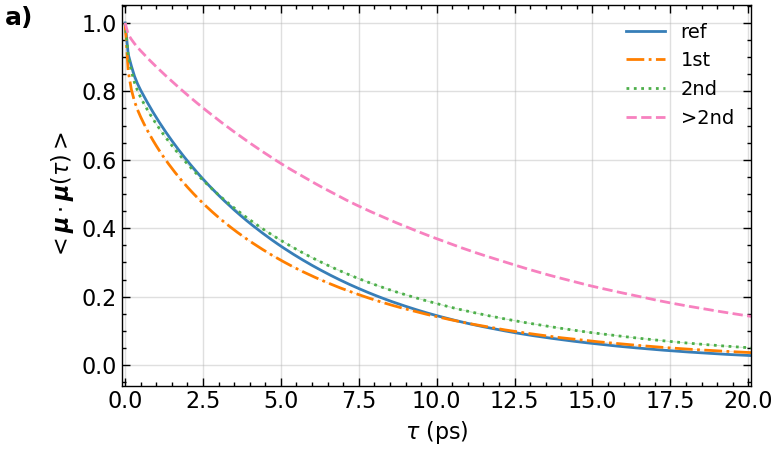

In [ ]:
fig, ax = plt.subplots()

#ax.set_xscale('log')
ax.set_xlabel("$\\tau$ (ps)")
ax.set_ylabel(u"$<\\mathrm{\\boldsymbol{\\mu}} \cdot \\mathrm{\\boldsymbol{\\mu}}(\\tau)>$")
#ax.set_title("Autocorelation of the different dipoles at room temperature")
ax.set_xlim(-0.1,20.1)
Name = "central"
Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[:,:]
Rescale = Data[0,1]
Data[:,1]/= Rescale
Data[:,2]/= Rescale
Data[:,0]/= 1000
prevplot = ax.plot(Data[:,0], Data[:,1], '-', label = "ref")
ax.fill_between(Data[:,0], Data[:,1]-Data[:,2], Data[:,1]+Data[:,2], alpha=0.3, lw=0)


Name = "1stshell"
Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[:,:]
Rescale = Data[0,1]
Data[:,1]/= Rescale
Data[:,2]/= Rescale
Data[:,0]/=1000
prevplot = ax.plot(Data[:,0], Data[:,1], '-.', label = "1st")
ax.fill_between(Data[:,0], Data[:,1]-Data[:,2], Data[:,1]+Data[:,2], alpha=0.3, lw=0)

Name = "2ndshell"
Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[:,:]
Rescale = Data[0,1]
Data[:,1]/= Rescale
Data[:,2]/= Rescale
Data[:,0]/=1000
prevplot = ax.plot(Data[:,0], Data[:,1], ':', label = "2nd")
ax.fill_between(Data[:,0], Data[:,1]-Data[:,2], Data[:,1]+Data[:,2], alpha=0.3, lw=0)

# Name = "out_1stshell"
# Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[1:,:]
# Rescale = Data\n[0,1] Data[:,1]/= Rescale
# Data[:,2]/=Data[0,1]
# Data[:,0]/=1000
# prevplot = ax.plot(Data[:,0], Data[:,1], label = Name)
# ax.fill_between(Data[:,0], Data[:,1]-Data[:,2], Data[:,1]+Data[:,2], alpha=0.3, lw=0)

Name = "out_2ndshell"
Data = np.loadtxt(f"dipole_{Name}_cor_mean_v3.txt")[:,:]
Rescale = Data[0,1]
Data[:,1]/= Rescale
Data[:,2]/= Rescale
Data[:,0]/=1000
prevplot = ax.plot(Data[:,0], Data[:,1], '--', label = ">2nd")
ax.fill_between(Data[:,0], Data[:,1]-Data[:,2], Data[:,1]+Data[:,2], alpha=0.3, lw=0)
fig.text(0.02,0.95, "a)",fontweight="bold",va="top", ha="left")

ax.legend()
ax.grid(alpha=0.4)
fig.set_size_inches((8,5))
plt.tight_layout()
plt.savefig("autocorr_RoomT.png")
plt.show()


<>:5: SyntaxWarning: invalid escape sequence '\c'
<>:5: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_81532/2454018229.py:5: SyntaxWarning: invalid escape sequence '\c'
  ax.set_ylabel(u"Rescaled $<\\mathrm{\\boldsymbol{\\mu}}_1 \cdot \\mathrm{\\boldsymbol{\\mu}}_2(\\tau)>$")


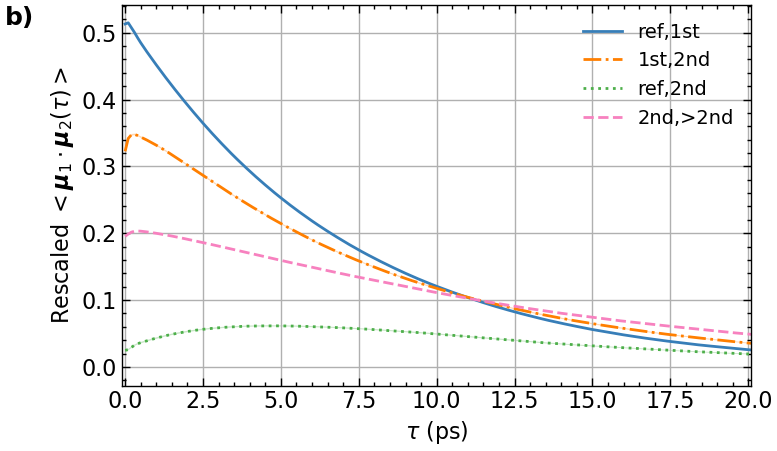

In [ ]:
fig, ax = plt.subplots()

#ax.set_xscale('log')
ax.set_xlabel(u"$\\tau$ (ps)")
ax.set_ylabel(u"Rescaled $<\\mathrm{\\boldsymbol{\\mu}}_1 \cdot \\mathrm{\\boldsymbol{\\mu}}_2(\\tau)>$")
ax.set_xlim((-0.1,20.1))

Name = "central_1stshell"
Subnames=Name.split('_')
Data = np.loadtxt(f"dipole_{Name}_crosscor_mean_v3.txt")[:,:]
Subdata1 = np.loadtxt(f"dipole_{Subnames[0]}_cor_mean_v3.txt")[:,:]
Subdata2 = np.loadtxt(f"dipole_{Subnames[1]}_cor_mean_v3.txt")[:,:]
Data[:,1]/=(np.sqrt(Subdata1[0,1]*Subdata2[0,1]))
Data[:,2]/=(np.sqrt(Subdata1[0,1]*Subdata2[0,1]))
Data[:,0]/=1000
prevplot = ax.plot(Data[:,0], Data[:,1], '-', label = "ref,1st")
ax.fill_between(Data[:,0], Data[:,1]-Data[:,2], Data[:,1]+Data[:,2], alpha=0.3, lw=0)

Name = "1stshell_2ndshell"
Subnames=Name.split('_')
Data = np.loadtxt(f"dipole_{Name}_crosscor_mean_v3.txt")[:,:]
Subdata1 = np.loadtxt(f"dipole_{Subnames[0]}_cor_mean_v3.txt")[:,:]
Subdata2 = np.loadtxt(f"dipole_{Subnames[1]}_cor_mean_v3.txt")[:,:]
Data[:,1]/=(np.sqrt(Subdata1[0,1]*Subdata2[0,1]))
Data[:,2]/=(np.sqrt(Subdata1[0,1]*Subdata2[0,1]))
Data[:,0]/=1000
prevplot = ax.plot(Data[:,0], Data[:,1], '-.', label = "1st,2nd")
ax.fill_between(Data[:,0], Data[:,1]-Data[:,2], Data[:,1]+Data[:,2], alpha=0.3, lw=0)

Name = "central_2ndshell"
Subnames=Name.split('_')
Data = np.loadtxt(f"dipole_{Name}_crosscor_mean_v3.txt")[:,:]
Subdata1 = np.loadtxt(f"dipole_{Subnames[0]}_cor_mean_v3.txt")[:,:]
Subdata2 = np.loadtxt(f"dipole_{Subnames[1]}_cor_mean_v3.txt")[:,:]
Data[:,1]/=(np.sqrt(Subdata1[0,1]*Subdata2[0,1]))
Data[:,2]/=(np.sqrt(Subdata1[0,1]*Subdata2[0,1]))
Data[:,0]/=1000
prevplot = ax.plot(Data[:,0], Data[:,1], ':', label = "ref,2nd")
ax.fill_between(Data[:,0], Data[:,1]-Data[:,2], Data[:,1]+Data[:,2], alpha=0.3, lw=0)


Name = "2nd_out2nd"
Subnames=Name.split('_')
Data = np.loadtxt(f"dipole_{Name}_crosscor_mean_v3.txt")[:,:]
Subdata1 = np.loadtxt(f"dipole_{Subnames[0]}_cor_mean_v3.txt")[:,:]
Subdata2 = np.loadtxt(f"dipole_{Subnames[1]}_cor_mean_v3.txt")[:,:]
Data[:,1]/=(np.sqrt(Subdata1[0,1]*Subdata2[0,1]))
Data[:,2]/=(np.sqrt(Subdata1[0,1]*Subdata2[0,1]))
Data[:,0]/=1000
prevplot = ax.plot(Data[:,0], Data[:,1], '--', label = "2nd,>2nd")
#ax.fill_between(Data[:,0], Data[:,1]-Data[:,2], Data[:,1]+Data[:,2], alpha=0.3, lw=0)
fig.text(0.02,0.95, "b)",fontweight="bold",va="top", ha="left")


ax.legend()
ax.grid()
fig.set_size_inches((8,5))
plt.tight_layout()
plt.savefig("crosscorr_RoomT.pdf")
plt.savefig("crosscorr_RoomT.png")

plt.show()
